**Install dependencies**

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

**STEP 1 — Load and understand the dataset**

In [29]:
iris = load_iris()
X = iris.data
y = iris.target

print("Dataset shape:", X.shape)
print("Classes:", iris.target_names)
print("Feature names:", iris.feature_names)
print("\nFirst 5 rows:\n", X[:5])
print("First 5 labels:", y[:5])


Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

First 5 rows:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
First 5 labels: [0 0 0 0 0]


**STEP 2 — Feature scaling**

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nBefore scaling - first sample:", X[0])
print("After scaling  - first sample:", X_scaled[0])



Before scaling - first sample: [5.1 3.5 1.4 0.2]
After scaling  - first sample: [-0.90068117  1.01900435 -1.34022653 -1.3154443 ]


**STEP 3 — Train / Test Split**

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")


Training samples : 120
Testing  samples : 30


**STEP 4 — Build and train the KNN model**

In [32]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("\nFirst 10 predictions:", predictions[:10])
print("Actual labels:       ", y_test[:10])



First 10 predictions: [0 2 1 1 0 1 0 0 2 1]
Actual labels:        [0 2 1 1 0 1 0 0 2 1]


**STEP 5 — Find the optimal K**

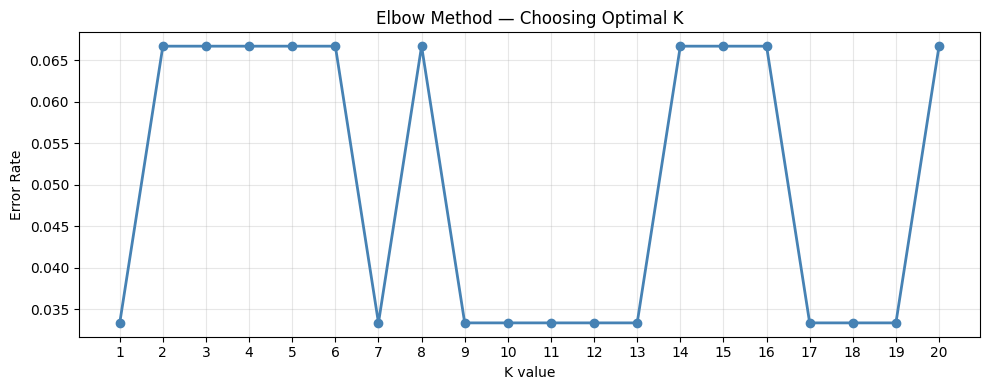

Best K: 1


In [33]:
error_rates = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, preds))

plt.figure(figsize=(10, 4))
plt.plot(k_range, error_rates, marker='o', color='steelblue', linewidth=2)
plt.xlabel("K value")
plt.ylabel("Error Rate")
plt.title("Elbow Method — Choosing Optimal K")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("elbow_curve.png", dpi=150)
plt.show()
print("Best K:", k_range[np.argmin(error_rates)])

**STEP 6 — Evaluate the model (Output Validation)**

In [34]:
accuracy = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average='weighted')

print(f"\nAccuracy : {accuracy:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, predictions, target_names=iris.target_names))




Accuracy : 0.9333
F1 Score : 0.9327

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



**STEP 7 — Confusion Matrix**

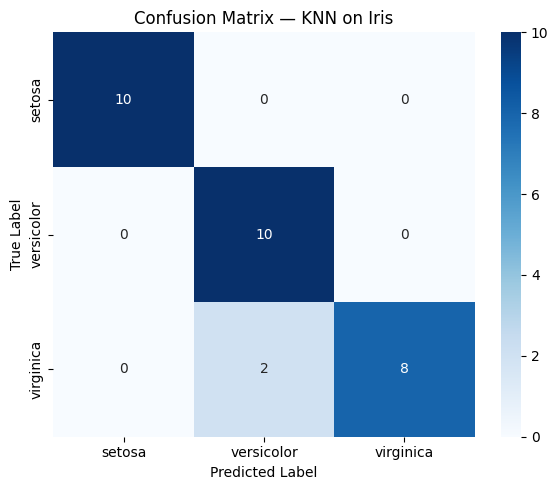

In [35]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — KNN on Iris")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

**Predict a new flower**

In [36]:
new_flower = np.array([[4.9, 3.1, 1.5, 0.1]])
new_flower_scaled = scaler.transform(new_flower)

prediction = model.predict(new_flower_scaled)
print(f"\nNew flower prediction: {iris.target_names[prediction[0]]}")


New flower prediction: setosa
